# 10 · Linear Regression

Correlation (notebook 07) told us **how strongly** two variables move together. Regression goes one step further: it gives us a **line** we can use to answer "if X goes up by 1, how much does Y change?" and to **predict** Y for a new X.

**What you will learn here**

1. The idea: the line that fits the data best
2. Least squares: the formula for the slope and intercept, worked out by hand
3. R²: how much of the variation the line explains
4. Is the slope real? t-test and confidence interval for the slope
5. Checking the assumptions with residuals, and what to do when the spread is not constant
6. Log-log regression and elasticity: a 170-year-old economic law in one number
7. Influential points (Cook's distance)
8. Predicting: confidence interval vs prediction interval

> **Colour guide:** $\color{red}{\text{red}}$ marks a rejected null hypothesis, a warning or a wrong reading. $\color{green}{\text{green}}$ marks a null hypothesis we fail to reject, a passed check or a correct reading.

## The dataset: Engel food expenditure

In 1857 the statistician **Ernst Engel** collected the budgets of Belgian working-class households. From this kind of data he found what is now called **Engel's law**: the richer a household is, the **smaller the share** of its income it spends on food. We will rediscover that law with regression.

| | |
|---|---|
| **Name** | Engel food expenditure data |
| **Source** | Koenker & Bassett (1982), *Robust Tests of Heteroscedasticity based on Regression Quantiles*, Econometrica 50. Distributed with the R package [`quantreg`](https://CRAN.R-project.org/package=quantreg) and with [`statsmodels`](https://www.statsmodels.org/stable/datasets/generated/engel.html) |
| **Licence** | Public domain |
| **Rows** | 235 households |

A copy is saved in `data/engel.csv`.

| Column | Meaning |
|---|---|
| `income` | Yearly household income, in Belgian francs |
| `foodexp` | Yearly spending on food, in Belgian francs |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"

engel = pd.read_csv("../data/engel.csv")
print("Rows:", len(engel))
engel.describe().round(1)

Rows: 235


,income,foodexp
count,235.0,235.0
mean,982.5,624.2
std,519.2,276.5
min,377.1,242.3
25%,638.9,429.7
50%,884.0,582.5
75%,1164.0,743.9
max,4957.8,2032.7


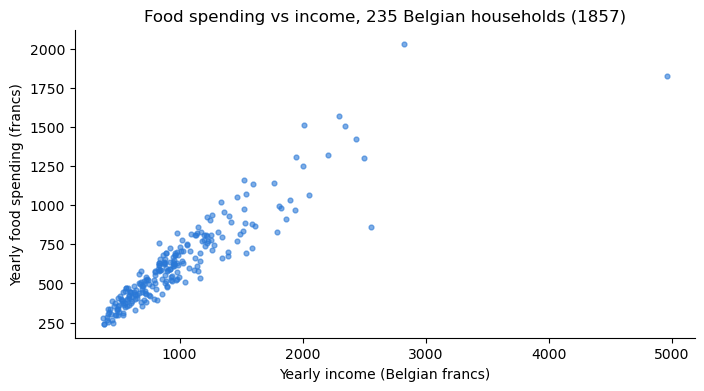

In [2]:
fig, ax = plt.subplots()
ax.scatter(engel["income"], engel["foodexp"], s=12, color=BLUE, alpha=0.6)
ax.set_title("Food spending vs income, 235 Belgian households (1857)")
ax.set_xlabel("Yearly income (Belgian francs)")
ax.set_ylabel("Yearly food spending (francs)")
plt.show()

Richer households spend more on food, and the points look roughly like a straight line. Notice two things we will come back to: the cloud **gets wider** as income grows, and there is one household far to the right.

---
## 1. The idea: the best line

> **Theory.** A straight line is $\hat{y} = b_0 + b_1 x$.
>
> - $b_1$ (**slope**): how much $y$ changes when $x$ goes up by 1
> - $b_0$ (**intercept**): the value of $y$ when $x = 0$
> - $\hat{y}$ ("y hat"): the value the line **predicts**

For every point, the **residual** is the gap between the real value and the line: $e_i = y_i - \hat{y}_i$. A good line has small residuals.

**Least squares** picks the line that makes the **sum of squared residuals** as small as possible. We square them so that points above and below the line don't cancel out (the same trick as for the variance in notebook 02).

---
## 2. The formula, by hand

**Formula**

$$b_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} = \frac{\text{Cov}(X, Y)}{\text{Var}(X)} \qquad b_0 = \bar{y} - b_1 \bar{x}$$

The slope is the covariance from notebook 07 divided by the variance of X. The line always passes through the point $(\bar{x}, \bar{y})$.

**Small example:** 5 households with round numbers.

| household | income x | food y |
|---|---|---|
| A | 400 | 300 |
| B | 600 | 420 |
| C | 800 | 520 |
| D | 1000 | 600 |
| E | 1200 | 700 |

**Manual calculation.** $\bar{x} = 800$, $\bar{y} = 508$

| x − 800 | y − 508 | product | (x − 800)² |
|---|---|---|---|
| −400 | −208 | 83,200 | 160,000 |
| −200 | −88 | 17,600 | 40,000 |
| 0 | 12 | 0 | 0 |
| 200 | 92 | 18,400 | 40,000 |
| 400 | 192 | 76,800 | 160,000 |
| | **sum** | **196,000** | **400,000** |

- $b_1 = 196{,}000 / 400{,}000 = 0.49$
- $b_0 = 508 - 0.49 \times 800 = 116$

The line is $\hat{y} = 116 + 0.49\,x$: each extra franc of income goes with 0.49 more francs spent on food.

In [3]:
x_small = np.array([400, 600, 800, 1000, 1200])
y_small = np.array([300, 420, 520, 600, 700])

slope_by_hand = ((x_small - x_small.mean()) * (y_small - y_small.mean())).sum() / ((x_small - x_small.mean()) ** 2).sum()
intercept_by_hand = y_small.mean() - slope_by_hand * x_small.mean()
print(f"by hand : b0 = {intercept_by_hand:.2f}, b1 = {slope_by_hand:.4f}")

# docs: https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html
slope_np, intercept_np = np.polyfit(x_small, y_small, deg=1)
print(f"np.polyfit: b0 = {intercept_np:.2f}, b1 = {slope_np:.4f}")

by hand : b0 = 116.00, b1 = 0.4900
np.polyfit: b0 = 116.00, b1 = 0.4900


> **Check:** Same line by hand and with numpy.

---
## 3. R²: how good is the line?

> **Theory.** Without any line, our best guess for every household would be the mean $\bar{y}$. R² measures how much of that "guess the mean" error the line removes.

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

R² goes from 0 (the line is no better than the mean) to 1 (all points exactly on the line). With one X variable, R² is simply Pearson's r squared.

**Manual calculation** on the 5 households. Predictions $116 + 0.49x$ = 312, 410, 508, 606, 704.

- Residuals: −12, 10, 12, −6, −4 (they always add up to 0)
- $SS_{res} = 144 + 100 + 144 + 36 + 16 = 440$
- $SS_{tot} = 208^2 + 88^2 + 12^2 + 92^2 + 192^2 = 96{,}480$
- $R^2 = 1 - 440 / 96{,}480 = 0.995$

In [4]:
y_hat_small = intercept_by_hand + slope_by_hand * x_small
ss_res = ((y_small - y_hat_small) ** 2).sum()
ss_tot = ((y_small - y_small.mean()) ** 2).sum()
print("residuals:", y_small - y_hat_small)
print(f"R² by hand = {1 - ss_res / ss_tot:.4f}")
print(f"Pearson r² = {np.corrcoef(x_small, y_small)[0, 1] ** 2:.4f}")

residuals: [-12.  10.  12.  -6.  -4.]
R² by hand = 0.9954
Pearson r² = 0.9954


### On the real data

Now the 235 households, with `statsmodels`. The formula `"foodexp ~ income"` means "explain foodexp with income" (an intercept is added automatically).

In [5]:
x = engel["income"]
y = engel["foodexp"]
slope_hand = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean()) ** 2).sum()
intercept_hand = y.mean() - slope_hand * x.mean()
print(f"by hand    : b0 = {intercept_hand:.2f}, b1 = {slope_hand:.4f}")

# docs: https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html
model = smf.ols("foodexp ~ income", data=engel).fit()
print(f"statsmodels: b0 = {model.params['Intercept']:.2f}, b1 = {model.params['income']:.4f}")
print(f"R² = {model.rsquared:.3f}   (Pearson r = {np.corrcoef(x, y)[0, 1]:.3f}, r² = {np.corrcoef(x, y)[0, 1] ** 2:.3f})")

by hand    : b0 = 147.48, b1 = 0.4852
statsmodels: b0 = 147.48, b1 = 0.4852
R² = 0.830   (Pearson r = 0.911, r² = 0.830)


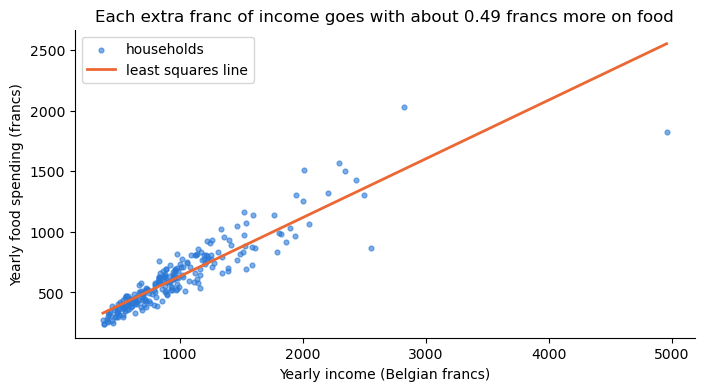

In [6]:
income_grid = np.linspace(x.min(), x.max(), 100)
fig, ax = plt.subplots()
ax.scatter(x, y, s=12, color=BLUE, alpha=0.6, label="households")
ax.plot(income_grid, model.params["Intercept"] + model.params["income"] * income_grid, color=ORANGE, linewidth=2, label="least squares line")
ax.set_title("Each extra franc of income goes with about 0.49 francs more on food")
ax.set_xlabel("Yearly income (Belgian francs)")
ax.set_ylabel("Yearly food spending (francs)")
ax.legend()
plt.show()

**Reading this:** the slope is **0.485**: on average, a household with 100 more francs of income spends about 49 more francs on food. R² = **0.83**, so income explains 83% of the variation in food spending.

> **Note:** The intercept (147 francs at zero income) is outside the data (the poorest household earns 377), so we should not read it literally. It just positions the line.

---
## 4. Is the slope real?

> **Theory.** Our 235 households are a sample. With another sample the slope would be a bit different. So we test it like any other estimate (notebook 05):
>
> - **H₀:** the true slope is 0 (income has no linear link with food spending)
> - **H₁:** the true slope is not 0

$$t = \frac{b_1 - 0}{SE(b_1)} \qquad SE(b_1) = \sqrt{\frac{SS_{res} / (n-2)}{\sum (x_i - \bar{x})^2}}$$

We lose 2 degrees of freedom because the line used 2 estimated numbers ($b_0$ and $b_1$).

In [7]:
n = len(engel)
residuals = y - (intercept_hand + slope_hand * x)
se_slope_hand = np.sqrt((residuals ** 2).sum() / (n - 2) / ((x - x.mean()) ** 2).sum())
t_hand = slope_hand / se_slope_hand
print(f"by hand    : SE = {se_slope_hand:.4f}, t = {t_hand:.1f}")
print(f"statsmodels: SE = {model.bse['income']:.4f}, t = {model.tvalues['income']:.1f}, p = {model.pvalues['income']:.1e}")
low, high = model.conf_int().loc["income"]
print(f"95% CI for the slope: [{low:.3f}, {high:.3f}]")

by hand    : SE = 0.0144, t = 33.8
statsmodels: SE = 0.0144, t = 33.8, p = 9.9e-92
95% CI for the slope: [0.457, 0.513]


t ≈ 34 and p is basically 0 → $\color{red}{\text{reject } H_0}$. The 95% confidence interval for the slope is about **[0.457, 0.513]**.

The full summary table from `statsmodels` shows all of this in one place:

In [8]:
print(model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    147.4754     15.957      9.242      0.000     116.037     178.914
income         0.4852      0.014     33.772      0.000       0.457       0.513


---
## 5. Checking the assumptions

A p-value is only as good as the assumptions behind it. Linear regression assumes:

| Assumption | How to check | If it fails |
|---|---|---|
| **L**inear relationship | Scatter plot, residual plot without a curve | Transform X or Y (section 6) |
| **I**ndependent observations | Study design (each household counted once) | Methods for grouped or time data |
| **N**ormal residuals | Histogram or Q-Q plot of residuals | With large n the CLT helps |
| **E**qual spread of residuals (homoscedasticity) | Residuals vs fitted plot, Breusch-Pagan test | Robust standard errors, or a log transform |

Easy to remember: **LINE**. The best single check is to plot the residuals against the fitted values.

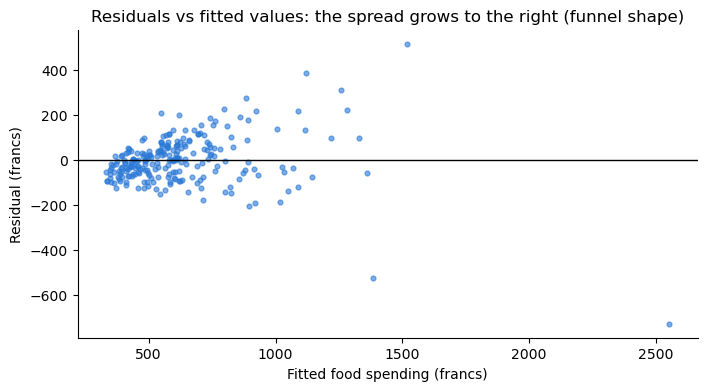

In [9]:
fig, ax = plt.subplots()
ax.scatter(model.fittedvalues, model.resid, s=12, color=BLUE, alpha=0.6)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Residuals vs fitted values: the spread grows to the right (funnel shape)")
ax.set_xlabel("Fitted food spending (francs)")
ax.set_ylabel("Residual (francs)")
plt.show()

The residuals fan out: the line is accurate for poor households but misses rich households by much more. This is called **heteroscedasticity** (unequal spread). It makes sense: a poor family has little room to choose, a rich family can spend a little or a lot on food.

> **Theory.** The **Breusch-Pagan test** checks this formally. H₀: the residual spread is constant. It regresses the squared residuals on X: if X can predict how big the errors are, the spread is not constant.

In [10]:
# docs: https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.het_breuschpagan.html
bp_stat, bp_p, _, _ = het_breuschpagan(model.resid, model.model.exog)
print(f"Breusch-Pagan: statistic = {bp_stat:.1f}, p = {bp_p:.1e}")

Breusch-Pagan: statistic = 109.3, p = 1.4e-25


p is tiny → $\color{red}{\text{reject } H_0}$: the spread is **not** constant.

**Why it matters:** the slope itself is still fine (unbiased), but the **standard error is wrong**, usually too small. So the t-test and the confidence interval look more certain than they really are.

**Fix 1: robust standard errors.** "HC3" standard errors don't assume equal spread. Same slope, more honest uncertainty:

In [11]:
# docs: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.get_robustcov_results.html
robust = model.get_robustcov_results(cov_type="HC3")
print(f"classic SE = {model.bse['income']:.4f}   CI = [{model.conf_int().loc['income'][0]:.3f}, {model.conf_int().loc['income'][1]:.3f}]")
print(f"robust  SE = {robust.bse[1]:.4f}   CI = [{robust.conf_int()[1][0]:.3f}, {robust.conf_int()[1][1]:.3f}]")
print(f"the robust SE is {robust.bse[1] / model.bse['income']:.1f} times bigger")

classic SE = 0.0144   CI = [0.457, 0.513]
robust  SE = 0.0664   CI = [0.354, 0.616]
the robust SE is 4.6 times bigger


The honest standard error is about **4.6 times bigger**, and the confidence interval widens from about [0.46, 0.51] to about **[0.35, 0.62]**. The slope is still clearly above 0, so the conclusion survives, but the classic table was overconfident.

> **Key idea:** always look at the residual plot before trusting a regression table.

---
## 6. Log-log regression and elasticity

**Fix 2: change the scale.** Money data is often right-skewed (notebook 08). Taking the log of both variables pulls in the big values and often fixes a funnel.

> **Theory.** In the model $\log(y) = b_0 + b_1 \log(x)$, the slope has a very useful meaning: it is the **elasticity**, the **% change in y for a 1% change in x**.
>
> - $b_1 = 1$: food spending grows exactly as fast as income (food share stays the same)
> - $b_1 < 1$: food spending grows **slower** than income (food share falls)
> - $b_1 > 1$: grows faster (a "luxury" good)

Engel's law says that for food, $b_1 < 1$. Let's test it.

In [12]:
log_model = smf.ols("np.log(foodexp) ~ np.log(income)", data=engel).fit()
elasticity = log_model.params["np.log(income)"]
low, high = log_model.conf_int().loc["np.log(income)"]
print(f"elasticity = {elasticity:.3f}, 95% CI [{low:.3f}, {high:.3f}], R² = {log_model.rsquared:.3f}")

bp_stat_log, bp_p_log, _, _ = het_breuschpagan(log_model.resid, log_model.model.exog)
print(f"Breusch-Pagan on the log model: statistic = {bp_stat_log:.1f} (was {bp_stat:.1f}), p = {bp_p_log:.4f}")

elasticity = 0.856, 95% CI [0.816, 0.896], R² = 0.884
Breusch-Pagan on the log model: statistic = 14.1 (was 109.3), p = 0.0002


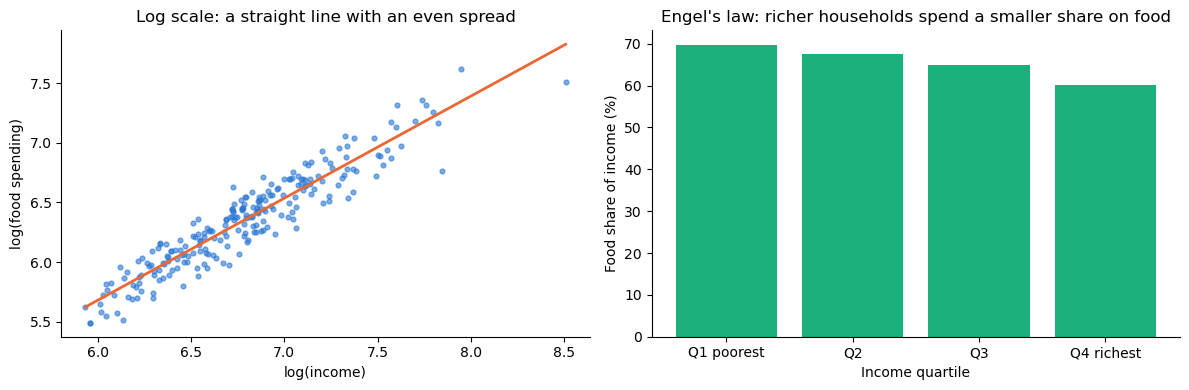

income_quartile
Q1 poorest    69.7
Q2            67.5
Q3            65.0
Q4 richest    60.1
Name: food_share, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(np.log(engel["income"]), np.log(engel["foodexp"]), s=12, color=BLUE, alpha=0.6)
log_grid = np.linspace(np.log(x.min()), np.log(x.max()), 100)
axes[0].plot(log_grid, log_model.params["Intercept"] + elasticity * log_grid, color=ORANGE, linewidth=2)
axes[0].set_title("Log scale: a straight line with an even spread")
axes[0].set_xlabel("log(income)")
axes[0].set_ylabel("log(food spending)")

engel["food_share"] = engel["foodexp"] / engel["income"]
engel["income_quartile"] = pd.qcut(engel["income"], 4, labels=["Q1 poorest", "Q2", "Q3", "Q4 richest"])
share_by_quartile = engel.groupby("income_quartile", observed=True)["food_share"].mean()
axes[1].bar(share_by_quartile.index.astype(str), share_by_quartile.values * 100, color=GREEN)
axes[1].set_title("Engel's law: richer households spend a smaller share on food")
axes[1].set_xlabel("Income quartile")
axes[1].set_ylabel("Food share of income (%)")
plt.tight_layout()
plt.show()
print((share_by_quartile * 100).round(1))

**Reading this:**

- The elasticity is **0.86** (95% CI about [0.82, 0.90]). The whole interval is below 1, so a 10% richer household spends only about 8.6% more on food. That is **Engel's law**, found again with one regression.
- The bar chart shows the same thing in plain numbers: the poorest quarter spends about **70%** of its income on food, the richest quarter about **60%**.
- The log scale made the funnel much smaller (Breusch-Pagan statistic from about 109 down to about 14). It is still significant, so we would keep robust standard errors here too.

---
## 7. Influential points

Remember the household far to the right? A single point with an extreme X can pull the whole line towards it.

> **Theory.** **Cook's distance** measures how much all the predictions would change if we removed one point. A common rule of thumb flags points with $D > 4/n$.

In [14]:
# docs: https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.OLSInfluence.html
cooks_d = model.get_influence().cooks_distance[0]
most_influential = int(np.argmax(cooks_d))
print(f"threshold 4/n = {4 / n:.3f}, points above it: {(cooks_d > 4 / n).sum()}")
print(f"most influential household: income = {x.iloc[most_influential]:.0f}, food = {y.iloc[most_influential]:.0f}, Cook's D = {cooks_d[most_influential]:.1f}")

without = engel.drop(index=engel.index[most_influential])
model_without = smf.ols("foodexp ~ income", data=without).fit()
log_model_without = smf.ols("np.log(foodexp) ~ np.log(income)", data=without).fit()
print(f"\nlinear slope    : {model.params['income']:.3f} with it, {model_without.params['income']:.3f} without it")
print(f"log-log slope   : {elasticity:.3f} with it, {log_model_without.params['np.log(income)']:.3f} without it")

threshold 4/n = 0.017, points above it: 10
most influential household: income = 4958, food = 1827, Cook's D = 9.3

linear slope    : 0.485 with it, 0.547 without it
log-log slope   : 0.856 with it, 0.869 without it


One household (income about 4,958 francs, 5 times the average) has a Cook's distance of about **9**, far above the 0.017 threshold. Removing it moves the linear slope from **0.485 to 0.547**, a big change from one point out of 235. On the log scale the elasticity barely moves (**0.856 to 0.869**), another reason the log model is the better choice here.

> $\color{red}{\text{Warning:}}$ don't delete a point just because it is influential. This household is real. The right move is to report it, and prefer a model that does not depend on one point.

---
## 8. Predicting: two kinds of intervals

For a household with an income of 1,000 francs, what food spending do we expect? There are two different questions:

| Interval | Question it answers | Width |
|---|---|---|
| **Confidence interval** for the mean | Where is the **average** food spending of all households earning 1,000? | Narrow |
| **Prediction interval** | Where will **one single** household earning 1,000 fall? | Wide: adds the household-to-household noise |

In [15]:
# docs: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.get_prediction.html
prediction = model.get_prediction(pd.DataFrame({"income": [1000]})).summary_frame(alpha=0.05)
print(f"predicted food spending : {prediction['mean'].iloc[0]:.0f} francs")
print(f"95% CI (average)        : [{prediction['mean_ci_lower'].iloc[0]:.0f}, {prediction['mean_ci_upper'].iloc[0]:.0f}]")
print(f"95% prediction interval : [{prediction['obs_ci_lower'].iloc[0]:.0f}, {prediction['obs_ci_upper'].iloc[0]:.0f}]")

predicted food spending : 633 francs
95% CI (average)        : [618, 647]
95% prediction interval : [407, 858]


The **average** household at 1,000 francs spends about 633 francs on food, known within about ±15 francs. But **one** household could be anywhere from about 407 to 858. Mixing up these two intervals is a very common mistake.

> **Note:** this prediction interval assumes equal spread, which we saw is not true. It is probably too wide for poor households and too narrow for rich ones.

> **Correlation is not causation (again).** The regression shows that income and food spending move together. It does not prove that giving a household more money **causes** it to spend 0.49 of it on food. For a causal answer we need an experiment, which is exactly what the A/B test notebooks are about.

---
## Summary

| Step | What we did |
|---|---|
| Line | $\hat{y} = b_0 + b_1 x$, slope = Cov(X, Y) / Var(X) |
| Fit | Least squares: minimise the sum of squared residuals |
| How good? | R² = 1 − SS_res / SS_tot (here 0.83) |
| Is the slope real? | t = b₁ / SE(b₁), confidence interval for the slope |
| Assumptions | LINE. Always plot residuals vs fitted values |
| Unequal spread | Breusch-Pagan test → robust (HC3) standard errors or a log transform |
| Log-log slope | Elasticity: % change in y for 1% change in x (here 0.86, Engel's law) |
| Influential points | Cook's distance, report them, prefer models that don't depend on one point |
| Prediction | Confidence interval for the average vs prediction interval for one case |

## What's next

Linear regression predicts a **number**. In notebook 11 we predict a **yes/no** outcome (did a passenger survive? did a player come back?) with **logistic regression**.

## References and further reading

- [OpenIntro Statistics](https://www.openintro.org/book/os/) (free textbook), chapter 8 (introduction to linear regression)
- [Engel's law, Wikipedia](https://en.wikipedia.org/wiki/Engel%27s_law) · [Heteroscedasticity, Wikipedia](https://en.wikipedia.org/wiki/Homoscedasticity_and_heteroscedasticity) · [Cook's distance, Wikipedia](https://en.wikipedia.org/wiki/Cook%27s_distance)
- [statsmodels `ols`](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html) · [statsmodels `het_breuschpagan`](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.het_breuschpagan.html)